# Kuhn Poker tests for weeks 08, 09, and 10

This notebook tests the implementations in `templates/` on Kuhn Poker. It checks:

- **Week 08:** normal-form conversion, sequence-form conversion, and a sequence-form equilibrium
- **Week 09:** CFR and CFR+ strategy validity and convergence
- **Week 10:** discounted CFR and Monte Carlo CFR strategy validity and convergence

Run all cells from the repository root. Individual failures are recorded instead of stopping the notebook; inspect the final summary and any traceback printed by a failing check. The exact stochastic result for Monte Carlo CFR can vary, so its threshold is deliberately looser.

In [1]:
from pathlib import Path
import sys
import time
import traceback

import matplotlib.pyplot as plt
import numpy as np

# Work whether Jupyter starts in the repository root or beside this notebook.
candidates = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next((p for p in candidates if (p / 'templates').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not find the repository root containing templates/.')

TEMPLATES = REPO_ROOT / 'templates'
if str(TEMPLATES) not in sys.path:
    sys.path.insert(0, str(TEMPLATES))

import kuhn_poker
import week07
import week08
import week09
import week10

# Increase these for a more demanding convergence test.
ITERATIONS = 1_000
MC_ITERATIONS = 10_000
MC_SEED = 0
PLOT_POINTS = 100
KUHN_VALUE = -1 / 18  # Value to player 0 at equilibrium.

print(f'Repository: {REPO_ROOT}')
print(f'CFR iterations: {ITERATIONS:,}; MCCFR iterations: {MC_ITERATIONS:,}')

Repository: /home/no433721/Codes/algorithmic_game_theory
CFR iterations: 1,000; MCCFR iterations: 10,000


## Shared game tree and test helpers

In [2]:
env = kuhn_poker.KuhnPokerNumpy()
root, info_sets = week07.traverse_tree(env)

assert root.is_chance
assert len(info_sets) == 12, f'Expected 12 information sets, got {len(info_sets)}'
assert set(int(nodes[0].player) for nodes in info_sets.values()) == {0, 1}

RESULTS = {}
HISTORIES = {}
CURVES = {}

def run_check(name, check):
    start = time.perf_counter()
    try:
        details = check()
    except Exception as exc:
        elapsed = time.perf_counter() - start
        RESULTS[name] = ('FAIL', elapsed, f'{type(exc).__name__}: {exc}')
        print(f'FAIL  {name} ({elapsed:.2f}s)')
        traceback.print_exc(limit=4)
        return None
    elapsed = time.perf_counter() - start
    RESULTS[name] = ('PASS', elapsed, str(details) if details is not None else '')
    print(f'PASS  {name} ({elapsed:.2f}s): {details}')
    return details

def assert_behavioral_profile(profile):
    assert set(profile) == {0, 1}, f'Expected players 0 and 1, got {set(profile)}'
    for info_set, nodes in info_sets.items():
        node = nodes[0]
        assert info_set in profile[node.player], f'Missing strategy for {info_set}'
        local = np.asarray(profile[node.player][info_set], dtype=float)
        legal = np.asarray(node.legal_action_mask, dtype=bool)
        assert local.shape == legal.shape
        assert np.all(np.isfinite(local))
        assert np.all(local >= -1e-10)
        assert np.allclose(local[~legal], 0.0, atol=1e-10)
        assert np.isclose(local[legal].sum(), 1.0, atol=1e-8)

def sampled_exploitability(history, max_points=PLOT_POINTS):
    assert history, 'The algorithm returned an empty history.'
    indices = np.unique(np.linspace(0, len(history) - 1, min(max_points, len(history)), dtype=int))
    profiles = [history[i] for i in indices]
    values = np.asarray(week07.compute_exploitability(root, info_sets, profiles, plot=False))
    assert np.all(np.isfinite(values))
    return indices + 1, values

print(f'Built Kuhn Poker with {len(info_sets)} information sets.')

Built Kuhn Poker with 12 information sets.


## Week 08 — normal form and sequence form

In [3]:
def check_normal_form():
    row_payoffs, col_payoffs = week08.convert_to_normal_form(root)
    row_payoffs = np.asarray(row_payoffs)
    col_payoffs = np.asarray(col_payoffs)
    assert row_payoffs.shape == (64, 64)
    assert col_payoffs.shape == row_payoffs.shape
    assert np.all(np.isfinite(row_payoffs))
    assert np.allclose(row_payoffs + col_payoffs, 0.0, atol=1e-10)
    return f'shape={row_payoffs.shape}, payoff range=[{row_payoffs.min():.3g}, {row_payoffs.max():.3g}]'

run_check('week08.convert_to_normal_form', check_normal_form)

PASS  week08.convert_to_normal_form (0.36s): shape=(64, 64), payoff range=[-1.33, 1.5]


'shape=(64, 64), payoff range=[-1.33, 1.5]'

In [4]:
SEQUENCE_FORM = None

def check_sequence_form():
    global SEQUENCE_FORM
    result = week08.convert_to_sequence_form(root)
    assert len(result) == 6, 'Expected (A, B, E, e, F, f).'
    A, B, E, e, F, f = map(np.asarray, result)
    assert A.shape == (13, 13), f'Unexpected sequence payoff shape: {A.shape}'
    assert B.shape == A.shape
    assert E.shape == (7, 13) and np.asarray(e).shape == (7,)
    assert F.shape == (7, 13) and np.asarray(f).shape == (7,)
    assert np.allclose(A + B, 0.0, atol=1e-10)
    assert np.all(np.isfinite(A))
    SEQUENCE_FORM = (A, B, E, e, F, f)
    return f'A={A.shape}, E={E.shape}, F={F.shape}'

run_check('week08.convert_to_sequence_form', check_sequence_form)

FAIL  week08.convert_to_sequence_form (0.00s)


Traceback (most recent call last):
  File "/tmp/ipykernel_32589/2141482722.py", line 15, in run_check
    details = check()
              ^^^^^^^
  File "/tmp/ipykernel_32589/2953611569.py", line 5, in check_sequence_form
    result = week08.convert_to_sequence_form(root)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/no433721/Codes/algorithmic_game_theory/templates/week08.py", line 144, in convert_to_sequence_form
    _collect_sequences(root, 0, player_1_sequences, (), player_1_parent_sequences, player_1_actions_at_info_set)
TypeError: _collect_sequences() missing 1 required positional argument: 'action_counts'


In [ ]:
def check_sequence_form_equilibrium():
    realization_0, realization_1 = week08.find_nash_equilibrium_sequence_form(root)
    realization_0 = np.asarray(realization_0, dtype=float)
    realization_1 = np.asarray(realization_1, dtype=float)

    # Get the constraints independently if the previous check was not run or failed.
    sequence_form = SEQUENCE_FORM
    if sequence_form is None:
        sequence_form = tuple(map(np.asarray, week08.convert_to_sequence_form(root)))
    _, _, E, e, F, f = sequence_form

    assert realization_0.shape == (E.shape[1],)
    assert realization_1.shape == (F.shape[1],)
    assert np.all(realization_0 >= -1e-9) and np.all(realization_1 >= -1e-9)
    assert np.allclose(E @ realization_0, e, atol=1e-7)
    assert np.allclose(F @ realization_1, f, atol=1e-7)

    profile = {
        0: week08.convert_realization_plan_to_behavioral_strategy(root, realization_0, 0),
        1: week08.convert_realization_plan_to_behavioral_strategy(root, realization_1, 1),
    }
    assert_behavioral_profile(profile)
    exploitability = week07.compute_exploitability(root, info_sets, [profile], plot=False)[0]
    value = float(week07.evaluate(root, profile)[0])
    assert exploitability < 1e-6
    assert abs(value - KUHN_VALUE) < 1e-6
    return f'value={value:.6f}, exploitability={exploitability:.3g}'

run_check('week08.find_nash_equilibrium_sequence_form', check_sequence_form_equilibrium)

## Weeks 09–10 — regret-minimization algorithms

Each test checks the history length, validates the final behavioral strategy, and measures exploitability. The final expected utility is also compared with Kuhn Poker's value, $-1/18$ for player 0.

In [5]:
def check_algorithm(name, train, iterations, max_exploitability, value_tolerance):
    history = train()
    assert len(history) == iterations, f'Expected {iterations} profiles, got {len(history)}'
    assert_behavioral_profile(history[-1])
    x, curve = sampled_exploitability(history)
    final_exploitability = float(curve[-1])
    value = float(week07.evaluate(root, history[-1])[0])
    assert final_exploitability < max_exploitability, (
        f'Final exploitability {final_exploitability:.6f} is not below {max_exploitability}.'
    )
    assert abs(value - KUHN_VALUE) < value_tolerance, (
        f'Player-0 value {value:.6f} is not close to {KUHN_VALUE:.6f}.'
    )
    HISTORIES[name] = history
    CURVES[name] = (x, curve)
    return f'value={value:.6f}, final exploitability={final_exploitability:.6f}'

In [6]:
run_check(
    'week09.cfr',
    lambda: check_algorithm(
        'CFR',
        lambda: week09.cfr(root, info_sets, ITERATIONS),
        ITERATIONS,
        max_exploitability=0.05,
        value_tolerance=0.03,
    ),
)

run_check(
    'week09.cfr_plus',
    lambda: check_algorithm(
        'CFR+',
        lambda: week09.cfr_plus(root, info_sets, ITERATIONS),
        ITERATIONS,
        max_exploitability=0.03,
        value_tolerance=0.02,
    ),
)

PASS  week09.cfr (0.31s): value=-0.055557, final exploitability=0.007269
PASS  week09.cfr_plus (0.40s): value=-0.055556, final exploitability=0.000087


'value=-0.055556, final exploitability=0.000087'

In [7]:
run_check(
    'week10.discounted_cfr',
    lambda: check_algorithm(
        'Discounted CFR',
        lambda: week10.discounted_cfr(
            root, info_sets, ITERATIONS, alpha=1.5, beta=0.0, gamma=2.0
        ),
        ITERATIONS,
        max_exploitability=0.03,
        value_tolerance=0.02,
    ),
)

run_check(
    'week10.monte_carlo_cfr',
    lambda: check_algorithm(
        'Monte Carlo CFR',
        lambda: week10.monte_carlo_cfr(root, info_sets, MC_ITERATIONS, MC_SEED),
        MC_ITERATIONS,
        max_exploitability=0.12,
        value_tolerance=0.08,
    ),
)

PASS  week10.discounted_cfr (0.37s): value=-0.055556, final exploitability=0.000147
FAIL  week10.monte_carlo_cfr (0.00s)


Traceback (most recent call last):
  File "/tmp/ipykernel_32589/2141482722.py", line 15, in run_check
    details = check()
              ^^^^^^^
  File "/tmp/ipykernel_32589/399944312.py", line 16, in <lambda>
    lambda: check_algorithm(
            ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_32589/1765420169.py", line 2, in check_algorithm
    history = train()
              ^^^^^^^
  File "/tmp/ipykernel_32589/399944312.py", line 18, in <lambda>
    lambda: week10.monte_carlo_cfr(root, info_sets, MC_ITERATIONS, MC_SEED),
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'p' is an invalid keyword argument for int()


## Convergence comparison

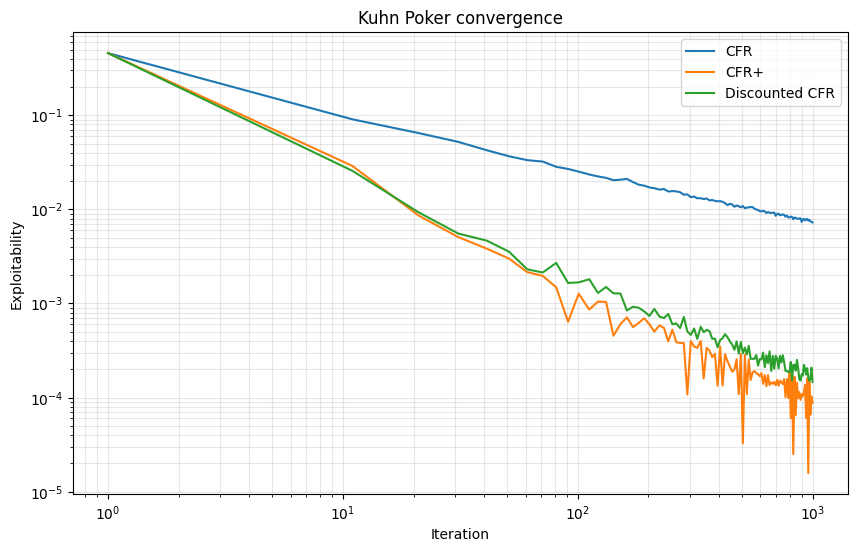

In [8]:
if CURVES:
    plt.figure(figsize=(10, 6))
    for name, (iterations, exploitability) in CURVES.items():
        plt.plot(iterations, exploitability, label=name)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Exploitability')
    plt.title('Kuhn Poker convergence')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('No algorithm completed successfully, so there are no curves to plot.')

## Summary

In [ ]:
print(f"{'Check':48} {'Status':6} {'Seconds':>8}  Details")
print('-' * 100)
for name, (status, elapsed, details) in RESULTS.items():
    print(f'{name:48} {status:6} {elapsed:8.2f}  {details}')

failed = [name for name, (status, _, _) in RESULTS.items() if status == 'FAIL']
print()
if failed:
    print(f'{len(failed)} check(s) failed: ' + ', '.join(failed))
else:
    print(f'All {len(RESULTS)} checks passed.')